In [1]:
import numpy as np
import cv2
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 500)
import matplotlib.patches as patches
import math
# pd.set_option('display.max_cols', 500)

In [2]:
df = pd.read_csv('data/mpii/annotations/trainval_unique.csv')

In [ ]:
def get_image_shape(image):
    # shape of image
    image_shape = image.shape
    if len(image_shape) == 3:
        height, width, num_chanels = image_shape
    else:
        height, width = image_shape
        num_chanels = 1
    return height, width, num_chanels

def get_bbox_parameters(visibility_array, joints_X, joints_Y, height, width, center):
    
    joints_X = np.array(joints_X) * width
    joints_Y = np.array(joints_Y) * height
    center = np.array(center)
    center[0] *= width
    center[1] *= height
    
    
    X_min = np.where(visibility_array>0, joints_X, np.Inf).min()
    X_max = np.where(visibility_array>0, joints_X, 0).max()
    Y_min = np.where(visibility_array>0, joints_Y, np.Inf).min()
    Y_max = np.where(visibility_array>0, joints_Y, 0).max()

    center_X = center[0]
    center_Y = center[1]
    dist_list = [X_min-center_X, X_max-center_X, Y_min-center_Y, Y_max-center_Y]
    max_distance = np.max(np.abs(dist_list))
    max_distance = max_distance + 0.1*height
    
    top_left = (center - max_distance)
    bottom_right = center + max_distance
    top_left = center - max_distance
    bottom_right = center + max_distance

    top_right = np.copy(center)
    top_right[0] += max_distance
    top_right[1] -= max_distance

    bottom_left = np.copy(center)
    bottom_left[0] -= max_distance
    bottom_left[1] += max_distance
    
    mode = 'crop' # 'crop' or 'extend'
    bbox_width = top_right[0] - top_left[0]
    bbox_height = bottom_left[1] - top_left[1]
#     bbox_width = bbox_height = math.ceil(max(bbox_height, bbox_width))
#     print(f'bbox_width: {bbox_width}\tbbox_width: {bbox_width}')
    
    if mode == 'crop':
        if top_left[0] < 0:
            top_left[0] = 0
        if top_left[1] < 0:
            top_left[1] = 0

        if bottom_right[0] > width:
            bottom_right[0] = width
        if bottom_right[1] > height:
            bottom_right[1] = height

        if top_right[0] > width:
            top_right[0] = width
        if top_right[1] < 0:
            top_right[1] = 0

        if bottom_left[0] < 0:
            bottom_left[0] = 0
        if bottom_left[1] > height:
            bottom_left[1] = height
            
        bbox_width = top_right[0] - top_left[0]
        bbox_height = bottom_left[1] - top_left[1]
        
        # crop the image containing the human according to the bounding box
        image_cropped = np.array(image[int(top_left[1]):int(bottom_left[1]), int(top_left[0]):int(top_right[0]), :])
        
        
    elif mode == 'extend':
        if top_left[0] < 0:
            shift = top_left[0]
            top_left[0] += shift
            top_right[0]  += shift
            bottom_left[0] += shift
            bottom_right[0] += shift
            
        if top_left[1] < 0:
            shift = top_left[1]
            top_left[1] += shift
            top_right[1]  += shift
            bottom_left[1] += shift
            bottom_right[1] += shift

        if bottom_right[0] > width:
            shift = -(width - bottom_right[0])
            top_left[0] += shift
            top_right[0]  += shift
            bottom_left[0] += shift
            bottom_right[0] += shift
            
        if bottom_right[1] > height:
            bottom_right[1] = height

        if top_right[0] > width:
            shift = -(width - top_right[0])
            top_left[0] += shift
            top_right[0]  += shift
            bottom_left[0] += shift
            bottom_right[0] += shift
        if top_right[1] < 0:
            top_right[1] = 0

        if bottom_left[0] < 0:
            bottom_left[0] = 0
        if bottom_left[1] > height:
            bottom_left[1] = height
            
        bbox_width = top_right[0] - top_left[0]
        bbox_height = bottom_left[1] - top_left[1]
        
        # crop the image containing the human according to the bounding box
        image_cropped = np.array(image[int(top_left[1]):int(bottom_left[1]), int(top_left[0]):int(top_right[0]), :])
    
    
    # for drawing the bbox
    bbox_top_left = top_left[0]-top_left[0]
    bbox_bottom_right = top_left[1]-top_left[1]
    
    
    
    return image_cropped, top_left, top_right, bottom_left, bottom_right, bbox_width, bbox_height, bbox_top_left, bbox_bottom_right

In [109]:
def display_overlaid_image(image, center, joints_X, joints_Y, bbox_top_left, bbox_bottom_right, bbox_width, bbox_height, visibility_array):
    
    joints_X = np.array(joints_X[joints_X>0])
    joints_Y = np.array(joints_Y[joints_Y>0])
    
    fig, ax = plt.subplots(1)
    fig.set_size_inches(18.5, 10.5)

    plt.imshow(image)
    plt.scatter(center[0], center[1], marker='o', color='y', s=500) # plot center of the human
    plt.scatter(joints_X, joints_Y, color='r', s=100) # plot the joints

    # draw bbox
    bbox = patches.Rectangle((bbox_top_left, bbox_bottom_right), bbox_width, bbox_height, linewidth=5, edgecolor='r', facecolor='none')
    ax.add_patch(bbox)
    plt.show()

[0.9140625  0.45277777]


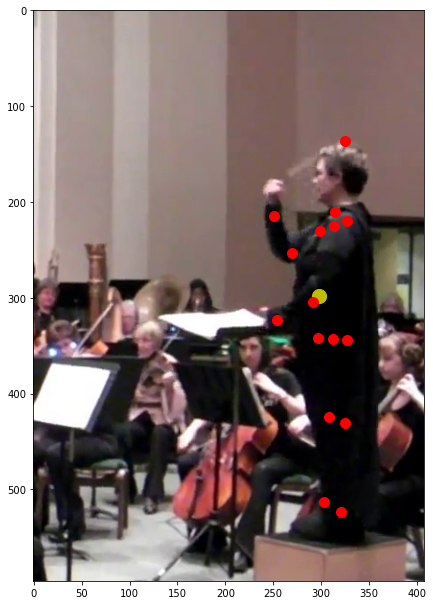

In [144]:
dataset_path = os.path.join('data', 'mpii')
annotations_path = os.path.join(dataset_path, 'annotations')
images_path = os.path.join(dataset_path, 'images')


# dataloader begins
sample_index = 5500
current_sample = df.iloc[sample_index] # row of dataframe
filename = current_sample[0] # name of the image file

full_path_image = os.path.join(images_path, filename) # full path to image file
image = cv2.cvtColor(cv2.imread(full_path_image, 1), cv2.COLOR_BGR2RGB) # image

height, width, num_chanels = get_image_shape(image)


center = np.array(current_sample[1:3]).astype(np.float32) # center of human
scale = np.array(current_sample[3]).astype(np.float32) # scale of human

joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
joints_X = np.array(joints_coordinates[::2]) # (X coordinates of joints)
joints_Y = np.array(joints_coordinates[1::2]) # (X coordinates of joints
visibility_array = np.array(current_sample[36:36+16]).astype(np.int64) # which joints are visible

# get the bounding box containing the human
image_cropped, top_left, top_right, bottom_left, bottom_right, bbox_width, bbox_height, bbox_top_left, bbox_bottom_right = get_bbox_parameters(visibility_array, joints_X, joints_Y, height, width, center)

# get cropped absolute coordinates (pixel)
joints_X_cropped_absolute = joints_X*width-top_left[0]
joints_Y_cropped_absolute = joints_Y*height-top_left[1]
joints_X_cropped_absolute = np.where(visibility_array>0, joints_X_cropped_absolute, -1)
joints_Y_cropped_absolute = np.where(visibility_array>0, joints_Y_cropped_absolute, -1)
center_cropped_absolute = (center[0]*width-top_left[0], center[1]*height-top_left[1])

# get cropped relative coordinates ([0, 1])
joints_X_cropped_relative = joints_X_cropped_absolute / bbox_width
joints_Y_cropped_relative = joints_Y_cropped_absolute / bbox_height
joints_X_cropped_relative = np.where(visibility_array>0, joints_X_cropped_relative, -1)
joints_Y_cropped_relative = np.where(visibility_array>0, joints_Y_cropped_relative, -1)

center_cropped = np.copy(center)
center_cropped[0] = center_cropped[0]*width-top_left[0]
center_cropped[1] = center_cropped[1]*height-top_left[1]
#################################################################################################################
# cropped image
#################################################################################################################

print(center)

# display_overlaid_image(image_cropped, center_cropped, joints_X_cropped_absolute, joints_Y_cropped_absolute, bbox_top_left, bbox_bottom_right, bbox_width, bbox_height, visibility_array)

# display_overlaid_image(image, [center[0]*width, center[1]*height], joints_X*width, joints_Y*height, top_left[0], top_left[1], bbox_width, bbox_height, visibility_array)
#################################################################################################################

fig, ax = plt.subplots(1)
fig.set_size_inches(18.5, 10.5)

# resized = cv2.resize(image, (224, 224))

plt.imshow(image_cropped)
plt.scatter(center_cropped[0], center_cropped[1], marker='o', color='y', s=200) # plot center of the human
plt.scatter(joints_X_cropped_relative*bbox_width, joints_Y_cropped_relative*bbox_height, color='r', s=100) # plot the joints
plt.show()


In [150]:
image_cropped.shape

(126, 125, 3)

In [99]:
# create 224 x 224 cropped images

dataset_path = os.path.join('data', 'mpii')
annotations_path = os.path.join(dataset_path, 'annotations')
save_path = os.path.join(dataset_path, 'images_cropped')

for sample_index in tqdm(range(len(df))):
    current_sample = df.iloc[sample_index] # row of dataframe
    filename = current_sample[0] # name of the image file

    full_path_image = os.path.join(images_path, filename) # full path to image file
    image = cv2.imread(full_path_image, 1) # image

    height, width, num_chanels = get_image_shape(image)


    center = np.array(current_sample[1:3]).astype(np.float32) # center of human
    scale = np.array(current_sample[3]).astype(np.float32) # scale of human

    joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
    joints_X = np.array(joints_coordinates[::2]) # (X coordinates of joints)
    joints_Y = np.array(joints_coordinates[1::2]) # (X coordinates of joints
    visibility_array = np.array(current_sample[36:36+16]).astype(np.int64) # which joints are visible

    # get the bounding box containing the human
    image_cropped, top_left, top_right, bottom_left, bottom_right, bbox_width, bbox_height, bbox_top_left, bbox_bottom_right = get_bbox_parameters(visibility_array, joints_X, joints_Y, height, width, center)

    save_fullpath = os.path.join(save_path, filename)
    resized = cv2.resize(image_cropped, (224, 224))
    cv2.imwrite(save_fullpath, resized)
    break

100%|████████████████████████████████████████████████████████████████████████████| 11522/11522 [07:56<00:00, 24.19it/s]


In [145]:
# update dataframe





dataset_path = os.path.join('data', 'mpii')
annotations_path = os.path.join(dataset_path, 'annotations')
images_path = os.path.join(dataset_path, 'images')

column_names = df.columns
df_cropped = pd.DataFrame(columns=column_names)

# dataloader begins
for sample_index in tqdm(range(len(df))):
    current_sample = df.iloc[sample_index] # row of dataframe
    filename = current_sample[0] # name of the image file

    full_path_image = os.path.join(images_path, filename) # full path to image file
    image = cv2.cvtColor(cv2.imread(full_path_image, 1), cv2.COLOR_BGR2RGB) # image

#     height, width, num_chanels = get_image_shape(image)
    height, width = 224, 224

    center = np.array(current_sample[1:3]).astype(np.float32) # center of human
    scale = np.array(current_sample[3]).astype(np.float32) # scale of human

    joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
    joints_X = np.array(joints_coordinates[::2]) # (X coordinates of joints)
    joints_Y = np.array(joints_coordinates[1::2]) # (X coordinates of joints
    visibility_array = np.array(current_sample[36:36+16]).astype(np.int64) # which joints are visible

    # get the bounding box containing the human
    image_cropped, top_left, top_right, bottom_left, bottom_right, bbox_width, bbox_height, bbox_top_left, bbox_bottom_right = get_bbox_parameters(visibility_array, joints_X, joints_Y, height, width, center)

    # get cropped absolute coordinates (pixel)
    joints_X_cropped_absolute = joints_X*width-top_left[0]
    joints_Y_cropped_absolute = joints_Y*height-top_left[1]
    joints_X_cropped_absolute = np.where(visibility_array>0, joints_X_cropped_absolute, -1)
    joints_Y_cropped_absolute = np.where(visibility_array>0, joints_Y_cropped_absolute, -1)
    center_cropped_absolute = (center[0]*width-top_left[0], center[1]*height-top_left[1])

    # get cropped relative coordinates ([0, 1])
    joints_X_cropped_relative = joints_X_cropped_absolute / bbox_width
    joints_Y_cropped_relative = joints_Y_cropped_absolute / bbox_height
    joints_X_cropped_relative = np.where(visibility_array>0, joints_X_cropped_relative, -1)
    joints_Y_cropped_relative = np.where(visibility_array>0, joints_Y_cropped_relative, -1)
    
    # reshape
    joints_cropped_relative_combined = np.zeros((len(joints_X_cropped_relative)*2)).astype(np.float32)
    joints_cropped_relative_combined[::2] = joints_X_cropped_relative
    joints_cropped_relative_combined[1::2] = joints_Y_cropped_relative
    
    height_width = np.array([bbox_height, bbox_width])

    numeric_values = np.concatenate((center, np.array(scale).reshape(1), joints_cropped_relative_combined, visibility_array, height_width))
    
    current_row = list([filename]) + list(numeric_values)
    df_cropped = df_cropped.append(pd.Series(current_row, index=column_names), ignore_index=True)

100%|████████████████████████████████████████████████████████████████████████████| 11522/11522 [06:21<00:00, 30.22it/s]


In [149]:
df_cropped

,filename,center_X,center_Y,scale,R_ANKLE_X,R_ANKLE_Y,R_KNEE_X,R_KNEE_Y,R_HIP_X,R_HIP_Y,L_HIP_X,L_HIP_Y,L_KNEE_X,L_KNEE_Y,L_ANKLE_X,L_ANKLE_Y,PELVIS_X,PELVIS_Y,THORAX_X,THORAX_Y,UPPER_NECK_X,UPPER_NECK_Y,HEAD_TOP_X,HEAD_TOP_Y,R_WRIST_X,R_WRIST_Y,R_ELBOW_X,R_ELBOW_Y,R_SHOULDER_X,R_SHOULDER_Y,L_SHOULDER_X,R_SHOULDER_Y.1,L_ELBOW_X,L_ELBOW_Y,L_WRIST_X,L_WRIST_Y,R_ANK_visibility,R_KN_visibility,R_H_visibility,L_H_visibility,L_KN_visibility,L_ANK_visibility,PELV_visibility,THOR_visibility,UPPER_NE_visibility,HEAD_T_visibility,R_WRI_visibility,R_ELB_visibility,R_SHOULD_visibility,L_SHOULD_visibility,L_ELB_visibility,L_WRI_visibility,height,width
0,060111501.jpg,0.700781,0.237500,3.806403,0.637438,0.764846,0.535921,0.755344,0.498456,0.589074,0.592722,0.536817,0.598765,0.688836,0.517792,0.828979,0.545589,0.562945,0.489996,0.320665,0.505934,0.428561,0.463181,0.139134,0.386061,0.698337,0.364308,0.586698,0.410232,0.349169,0.568551,0.292161,0.655566,0.387173,0.614476,0.529691,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,130.977783,144.802795
1,002058449.jpg,0.721875,0.618056,8.280870,0.657856,0.605908,0.413062,0.698460,0.464100,0.541718,0.715510,0.355122,0.945181,0.601429,0.710784,0.520819,0.589805,0.449166,0.487729,0.311831,0.541861,0.395268,0.355149,0.107480,0.207019,0.656662,0.211745,0.573067,0.356353,0.328252,0.619105,0.293918,0.841215,0.498428,0.746700,0.655169,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,208.411377,185.155838
2,029122914.jpg,0.438889,0.622917,2.204083,-1.000000,-1.000000,0.461479,0.982723,0.463012,0.669272,0.555002,0.666804,0.562667,0.975319,-1.000000,-1.000000,0.509007,0.669272,0.498275,0.350885,0.500219,0.299466,0.507063,0.118470,0.421617,0.553271,0.401686,0.555739,0.426217,0.358289,0.568800,0.341012,0.607129,0.577952,0.602529,0.531058,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,189.077881,202.922318
3,061185289.jpg,0.604167,0.614583,4.143112,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.675460,0.583260,0.644385,0.464920,0.555546,0.126605,0.363068,0.187621,0.489760,0.364340,0.640750,0.493582,0.708435,0.670301,-1.000000,-1.000000,-1.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,176.928864,179.262177
4,013949386.jpg,0.254167,0.681250,4.431105,-1.000000,-1.000000,-1.000000,-1.000000,0.160116,0.802083,0.302766,0.739583,-1.000000,-1.000000,-1.000000,-1.000000,0.231441,0.770833,0.275109,0.475000,0.278194,0.473107,0.475809,0.351893,0.534207,0.756250,0.369723,0.893750,0.241630,0.631250,0.308588,0.318750,0.464338,0.256250,0.547307,0.081250,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,224.000000,213.733322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11517,050240222.jpg,0.502344,0.445833,3.480000,0.474219,0.956944,0.467969,0.752778,0.472656,0.577778,0.539844,0.569444,0.550000,0.770833,0.557813,0.977778,0.506250,0.573611,0.467969,0.319444,0.464951,0.283824,0.451455,0.124509,0.326562,0.423611,0.368750,0.390278,0.417188,0.322222,0.517969,0.316667,0.486719,0.401389,0.433594,0.462500,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,224.000000,224.000000
11518,033474347.jpg,0.575781,0.397222,2.003677,0.653912,0.844488,0.586368,0.685039,0.546506,0.519685,0.505536,0.533465,0.465674,0.696850,0.502215,0.858268,0.526575,0.527559,0.441314,0.368110,0.427788,0.339040,0.380652,0.237731,0.451280,0.415354,0.487820,0.448819,0.463460,0.358268,0.418061,0.375984,0.430241,0.500000,0.382628,0.448819,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,158.044434,158.044434
11519,082650067.jpg,0.664844,0.504167,3.235820,0.775487,0.911111,0.693846,0.700000,0.650242,0.455556,0.583445,0.468056,0.564890,0.700000,0.603855,0.884722,0.616844,0.462500,0.5

In [148]:
df_cropped.to_csv('trainval_unique_cropped.csv', index=False)

In [4]:
dataset_path = os.path.join('data', 'mpii')
annotations_path = os.path.join(dataset_path, 'annotations')
images_path = os.path.join(dataset_path, 'images')
save_path = os.path.join(dataset_path, 'images_cropped')

column_names = df.columns
df_cropped = pd.DataFrame(columns=column_names)


# sample_index = 5500
for sample_index in tqdm(range(len(df))):
    current_sample = df.iloc[sample_index] # row of dataframe
    filename = current_sample[0] # name of the image file

    full_path_image = os.path.join(images_path, filename) # full path to image file
    image = cv2.imread(full_path_image, 1) # image

    height, width, num_chanels = get_image_shape(image)


    center = np.array(current_sample[1:3]).astype(np.float32) # center of human
    scale = np.array(current_sample[3]).astype(np.float32) # scale of human

    joints_coordinates = np.array(current_sample[4:4+32]).astype(np.float32) # 16 joints (32 coordinates)
    joints_X = np.array(joints_coordinates[::2]) # (X coordinates of joints)
    joints_Y = np.array(joints_coordinates[1::2]) # (X coordinates of joints
    visibility_array = np.array(current_sample[36:36+16]).astype(np.int64) # which joints are visible

    # get the bounding box containing the human
    image_cropped, top_left, top_right, bottom_left, bottom_right, bbox_width, bbox_height, bbox_top_left, bbox_bottom_right = get_bbox_parameters(visibility_array, joints_X, joints_Y, height, width, center)

    # get cropped absolute coordinates (pixel)
    joints_X_cropped_absolute = joints_X*width-top_left[0]
    joints_Y_cropped_absolute = joints_Y*height-top_left[1]
    joints_X_cropped_absolute = np.where(visibility_array>0, joints_X_cropped_absolute, -1)
    joints_Y_cropped_absolute = np.where(visibility_array>0, joints_Y_cropped_absolute, -1)
    center_cropped_absolute = (center[0]*width-top_left[0], center[1]*height-top_left[1])

    # get cropped relative coordinates ([0, 1])
    joints_X_cropped_relative = joints_X_cropped_absolute / bbox_width
    joints_Y_cropped_relative = joints_Y_cropped_absolute / bbox_height
    joints_X_cropped_relative = np.where(visibility_array>0, joints_X_cropped_relative, -1)
    joints_Y_cropped_relative = np.where(visibility_array>0, joints_Y_cropped_relative, -1)

    center_cropped = np.copy(center)
    center_cropped[0] = center_cropped[0]*width-top_left[0]
    center_cropped[1] = center_cropped[1]*height-top_left[1]

    # reshape
    joints_cropped_relative_combined = np.zeros((len(joints_X_cropped_relative)*2)).astype(np.float32)
    joints_cropped_relative_combined[::2] = joints_X_cropped_relative
    joints_cropped_relative_combined[1::2] = joints_Y_cropped_relative

    height, width, _ = image_cropped.shape
    height_width = np.array([height, width])

    numeric_values = np.concatenate((center, np.array(scale).reshape(1), joints_cropped_relative_combined, visibility_array, height_width))

    current_row = list([filename]) + list(numeric_values)
#     df_cropped = df_cropped.append(pd.Series(current_row, index=column_names), ignore_index=True)


    

    center_cropped[0] = center_cropped[0]/width
    center_cropped[1] = center_cropped[1]/height

    joints_X_cropped_relative = joints_X_cropped_relative*bbox_width/width
    joints_Y_cropped_relative = joints_Y_cropped_relative*bbox_height/height

    # reshape
    joints_cropped_relative_combined = np.zeros((len(joints_X_cropped_relative)*2)).astype(np.float32)
    joints_cropped_relative_combined[::2] = joints_X_cropped_relative
    joints_cropped_relative_combined[1::2] = joints_Y_cropped_relative


    image_cropped_reshaped = cv2.resize(image_cropped, (224, 224))

    height_width = np.array([224, 224])
    numeric_values = np.concatenate((center_cropped, np.array(scale).reshape(1), joints_cropped_relative_combined, visibility_array, height_width))
    current_row = list([filename]) + list(numeric_values)
    df_cropped = df_cropped.append(pd.Series(current_row, index=column_names), ignore_index=True)

    save_fullpath = os.path.join(save_path, filename)
    cv2.imwrite(save_fullpath, image_cropped_reshaped)
#     break
# fig, ax = plt.subplots(1)
# fig.set_size_inches(10, 10)
# plt.imshow(image_cropped_reshaped)
# plt.scatter(center_cropped[0]*224, center_cropped[1]*224, marker='o', color='y', s=200) # plot center of the human
# plt.scatter(joints_X_cropped_relative*224, joints_Y_cropped_relative*224, color='r', s=100) # plot the joints
# plt.show()

# # plt.imshow(image_cropped_reshaped)
# # plt.scatter(center_cropped[0]*224/width, center_cropped[1]*224/height, marker='o', color='y', s=200) # plot center of the human
# # plt.scatter(joints_X_cropped_relative*bbox_width*224/width, joints_Y_cropped_relative*bbox_height*224/height, color='r', s=100) # plot the joints
# # plt.show()

100%|████████████████████████████████████████████████████████████████████████████| 11522/11522 [07:23<00:00, 25.97it/s]


In [6]:
df_cropped

,filename,center_X,center_Y,scale,R_ANKLE_X,R_ANKLE_Y,R_KNEE_X,R_KNEE_Y,R_HIP_X,R_HIP_Y,L_HIP_X,L_HIP_Y,L_KNEE_X,L_KNEE_Y,L_ANKLE_X,L_ANKLE_Y,PELVIS_X,PELVIS_Y,THORAX_X,THORAX_Y,UPPER_NECK_X,UPPER_NECK_Y,HEAD_TOP_X,HEAD_TOP_Y,R_WRIST_X,R_WRIST_Y,R_ELBOW_X,R_ELBOW_Y,R_SHOULDER_X,R_SHOULDER_Y,L_SHOULDER_X,R_SHOULDER_Y.1,L_ELBOW_X,L_ELBOW_Y,L_WRIST_X,L_WRIST_Y,R_ANK_visibility,R_KN_visibility,R_H_visibility,L_H_visibility,L_KN_visibility,L_ANK_visibility,PELV_visibility,THOR_visibility,UPPER_NE_visibility,HEAD_T_visibility,R_WRI_visibility,R_ELB_visibility,R_SHOULD_visibility,L_SHOULD_visibility,L_ELB_visibility,L_WRI_visibility,height,width
0,060111501.jpg,0.5,0.406176,3.806403,0.666,0.764846,0.498,0.755344,0.436,0.589074,0.592,0.536817,0.602,0.688836,0.468,0.828979,0.514,0.562945,0.422,0.320665,0.448375,0.428562,0.377625,0.139134,0.25,0.698337,0.214,0.586698,0.29,0.349169,0.552,0.292162,0.696,0.387173,0.628,0.529691,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,224.0,224.0


In [5]:
df_cropped.to_csv('trainval_unique_cropped.csv', index=False)